# Player-Count Generalizable Training Analysis

This notebook compares the two training runs in this folder:

- `qnet_results.txt`: baseline `MLP+DQN` model.
- `encoder_results.txt`: optional `Encoder+DQN` architecture.

The focus is comparative visualization of **final performance** and **training speed** for the player-count generalizable setup. The logs aggregate training under stochastic player counts in the `[2, 4]` range, so the curves below describe mixed-player-count training performance rather than separate 2-, 3-, and 4-player evaluation slices.

In [16]:
from pathlib import Path
import os
import re

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-sushigo")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 160

RESULT_DIR = Path.cwd()
if RESULT_DIR.name != "player-count generalizable":
    RESULT_DIR = Path("results/player-count generalizable")

RUNS = {
    "large_qnet_results.txt": "MLP+DQN",
    "encoder_results.txt": "Encoder+DQN",
}

RESULT_DIR

PosixPath('/home/thlamz/SushiGo_MARL/results/player-count generalizable')

In [17]:
ANSI_RE = re.compile(r"\x1b\[[0-9;]*m")
LINE_RE = re.compile(
    r"iter\s+(?P<iteration>\d+)\s+\|\s+"
    r"loss=(?P<loss>[+-]?\d+(?:\.\d+)?)\s+\|\s+"
    r"eps=(?P<epsilon>[+-]?\d+(?:\.\d+)?)\s+\|\s+"
    r"mean turn reward=(?P<turn_reward>[+-]?\d+(?:\.\d+)?)\s+\|\s+"
    r"mean episode return/seat=(?P<episode_return>[+-]?\d+(?:\.\d+)?)"
)

def parse_log(path: Path, model_label: str) -> pd.DataFrame:
    rows = []
    for raw_line in path.read_text(errors="ignore").splitlines():
        line = ANSI_RE.sub("", raw_line)

        match = LINE_RE.search(line)
        if not match:
            continue

        row = match.groupdict()
        row = {key: float(value) for key, value in row.items()}
        row["iteration"] = int(row["iteration"])
        row["model"] = model_label
        row["file"] = path.name
        rows.append(row)

    return pd.DataFrame(rows)

frames = []
for file_name, label in RUNS.items():
    frame = parse_log(RESULT_DIR / file_name, label)
    frames.append(frame)

df = pd.concat(frames, ignore_index=True).sort_values(["model", "iteration"])

max_iteration = df["iteration"].max()
# The logs use 0-based iteration indexing, so iteration 4999 means 5000 logged updates.
df["progress"] = df["iteration"] / max_iteration

df.head()

,iteration,loss,epsilon,turn_reward,episode_return,model,file,progress
5000,0,0.0488,1.000,0.130,3.45,Encoder+DQN,encoder_results.txt,0.0000
5001,1,0.0388,0.999,0.129,3.40,Encoder+DQN,encoder_results.txt,0.0002
5002,2,0.0381,0.999,0.126,3.29,Encoder+DQN,encoder_results.txt,0.0004
5003,3,0.0376,0.999,0.133,3.51,Encoder+DQN,encoder_results.txt,0.0006
5004,4,0.0308,0.999,0.127,3.32,Encoder+DQN,encoder_results.txt,0.0008


In [18]:
run_summary = (
    df.groupby("model")
    .agg(
        logged_iterations=("iteration", "size"),
        first_return=("episode_return", "first"),
        final_return=("episode_return", "last"),
        best_return=("episode_return", "max"),
        final_turn_reward=("turn_reward", "last"),
        final_loss=("loss", "last"),
        final_epsilon=("epsilon", "last"),
    )
    .round(4)
)

run_summary

,logged_iterations,first_return,final_return,best_return,final_turn_reward,final_loss,final_epsilon
model,,,,,,,
Encoder+DQN,5000,3.45,4.51,4.70,0.172,0.0109,0.05
MLP+DQN,5000,3.35,4.45,4.72,0.170,0.0105,0.05


## Final Performance

/tmp/ipykernel_2400872/642282882.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


,model,loss_min,relative_loss_pct,loss_reduction_vs_mlp_pct
0,MLP+DQN,0.0086,100.0000,0.0000
1,Encoder+DQN,0.0088,102.3256,-2.3256


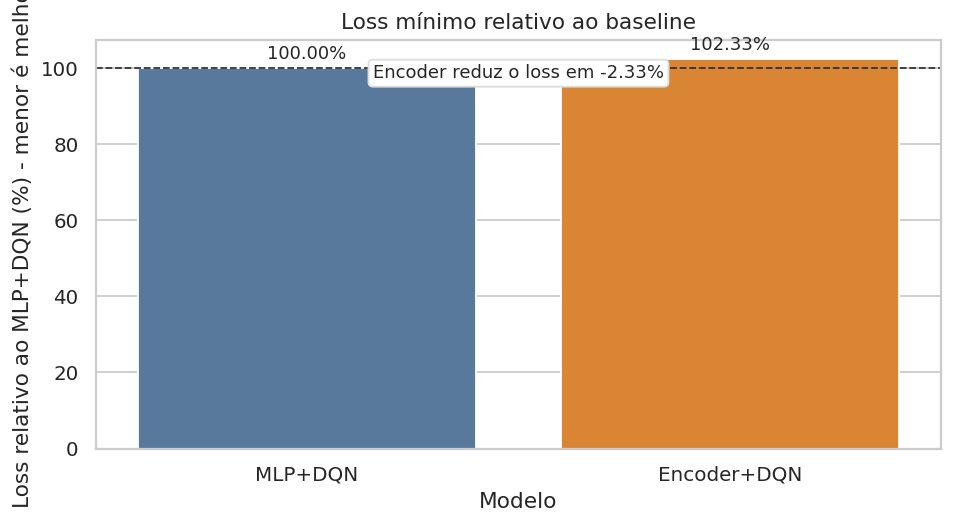

In [19]:
summary = (
    df.groupby("model", group_keys=False)
    .agg(
        loss_min=("loss", "min"),
    )
    .reset_index()
)

baseline_model = "MLP+DQN"
comparison_model = "Encoder+DQN"
model_order = [model for model in [baseline_model, comparison_model] if model in summary["model"].tolist()]
summary_ordered = summary.set_index("model").loc[model_order].reset_index()

baseline_loss = summary_ordered.loc[summary_ordered["model"] == baseline_model, "loss_min"].iloc[0]
summary_ordered["relative_loss_pct"] = summary_ordered["loss_min"] / baseline_loss * 100
summary_ordered["loss_reduction_vs_mlp_pct"] = 100 - summary_ordered["relative_loss_pct"]

encoder_reduction = summary_ordered.loc[
    summary_ordered["model"] == comparison_model, "loss_reduction_vs_mlp_pct"
].iloc[0]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.barplot(
    data=summary_ordered,
    x="model",
    y="relative_loss_pct",
    order=model_order,
    ax=ax,
    palette=["#4C78A8", "#F58518"],
)

ax.axhline(100, color="#333333", linewidth=1, linestyle="--")
ax.set_title("Loss mínimo relativo ao baseline")
ax.set_xlabel("Modelo")
ax.set_ylabel("Loss relativo ao MLP+DQN (%) - menor é melhor")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=10)

ax.text(
    0.5,
    0.94,
    f"Encoder reduz o loss em {encoder_reduction:.2f}%",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "#DDDDDD"},
)

plt.tight_layout()

summary_ordered.round(4)

## Training Speed

Training speed is summarized in two ways:

- smoothed learning curves, using a rolling mean over 100 logged iterations;
- threshold timing, measured by the first iteration where the 100-iteration rolling return reaches a target level.

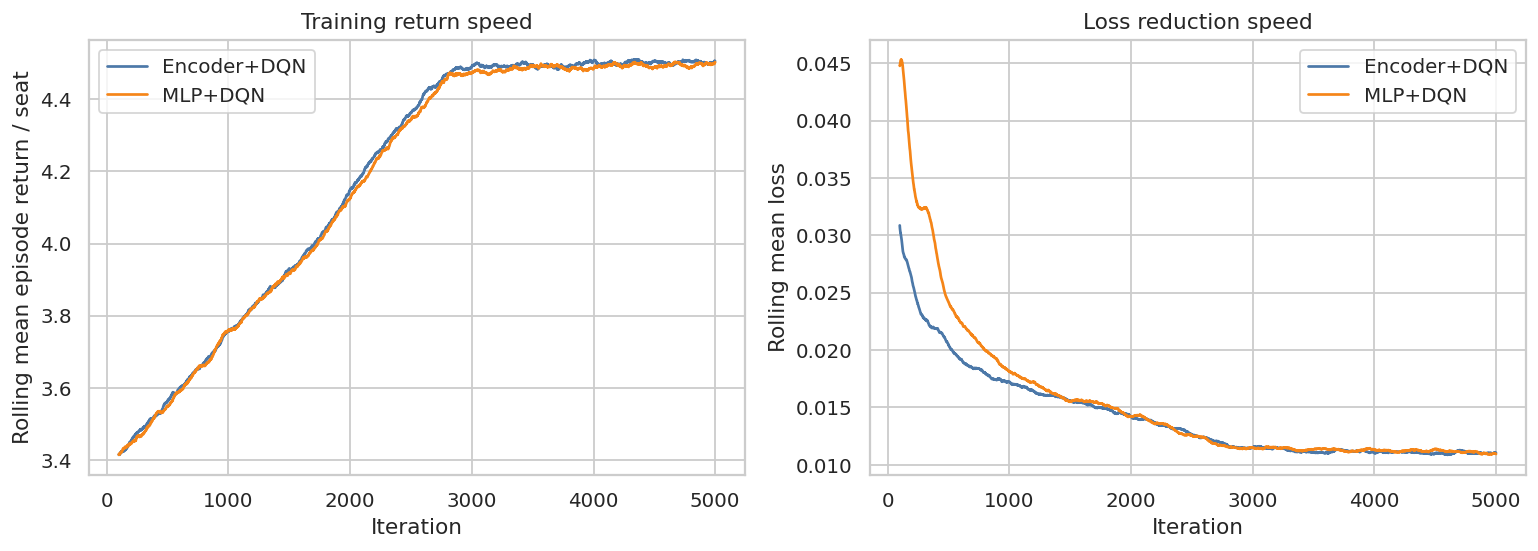

In [22]:
ROLLING_WINDOW = 100

curve_df = df.copy()
curve_df["return_roll100"] = (
    curve_df.groupby("model")["episode_return"]
    .transform(lambda values: values.rolling(ROLLING_WINDOW, min_periods=ROLLING_WINDOW).mean())
)
curve_df["loss_roll100"] = (
    curve_df.groupby("model")["loss"]
    .transform(lambda values: values.rolling(ROLLING_WINDOW, min_periods=ROLLING_WINDOW).mean())
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

sns.lineplot(
    data=curve_df,
    x="iteration",
    y="return_roll100",
    hue="model",
    ax=axes[0],
    palette=["#4C78A8", "#F58518"],
)
axes[0].set_title("Training return speed")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Rolling mean episode return / seat")
axes[0].legend(title="")

sns.lineplot(
    data=curve_df,
    x="iteration",
    y="loss_roll100",
    hue="model",
    ax=axes[1],
    palette=["#4C78A8", "#F58518"],
)
axes[1].set_title("Loss reduction speed")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Rolling mean loss")
axes[1].legend(title="")

plt.tight_layout()